In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [2]:
def load_data(npz_file_path):
    """
    Loads the aligned data from the .npz file.
    """
    if not os.path.exists(npz_file_path):
        print(f"Error: File not found at {npz_file_path}")
        print("Please run 'create_aligned_dataset.py' first.")
        return None, None, None

    print(f"Loading data from {npz_file_path}...")
    with np.load(npz_file_path) as data:
        features = data['features']
        labels = data['labels']
        ids = data['ids']
    
    print("Data loaded successfully.")
    return features, labels, ids

In [3]:
from matplotlib.pylab import mean


def preprocess_data(features, labels):

    print("Preprocessing data...")

    # Convert to float32
    X = features.astype(np.float32)

    # Normalize (very important)
    mean = np.mean(X,axis=(0,2), keepdims=True)
    std = np.std(X,axis=(0,2), keepdims=True)

    X = (X - mean) / (std + 1e-8)

    print(f"Mean after normalization: {np.mean(X):.4f}")
    print(f"Std after normalization: {np.std(X):.4f}")

    # Add channel dimension
    X = np.expand_dims(X, axis=-1)

    print(f"Features shape reshaped to: {X.shape}")

    # Encode labels
    encoder = LabelEncoder()
    y_integers = encoder.fit_transform(labels)
    y_one_hot = to_categorical(y_integers)

    print(f"Labels shape one-hot encoded to: {y_one_hot.shape}")

    return X, y_one_hot, encoder

In [4]:
def build_model(input_shape, num_classes):

    print("Building Optimized CNN model...")

    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)

    # Block 2
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)

    # Block 3
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling2D()(x)
    

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Optimized model built successfully.")
    return model

In [5]:
def plot_training_history(history):
    """
    Plots the accuracy and loss curves for training and validation.
    """
    print("Plotting training history...")
    
    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history.png')
    print("Saved training history plot to 'training_history.png'")
    # plt.show() # Uncomment this if running in an interactive environment


In [6]:
def evaluate_model(model, X_test, y_test, encoder):
    """
    Evaluates the model on the test set and prints a detailed report.
    """
    print("\n--- Model Evaluation ---")
    
    # Get final loss and accuracy on the test set
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'Test Accuracy: {accuracy * 100:.2f}%')
    print(f'Test Loss: {loss:.4f}')

    # --- Classification Report ---
    # Get model predictions (probabilities)
    y_pred_probs = model.predict(X_test)
    
    # Convert probabilities to class indices (e.g., [0.1, 0.8] -> 1)
    y_pred_indices = np.argmax(y_pred_probs, axis=1)
    
    # Convert one-hot true labels back to class indices
    y_test_indices = np.argmax(y_test, axis=1)
    
    # Get the string class names (e.g., 'happy', 'sad')
    class_names = encoder.classes_
    
    print("\nClassification Report:")
    print(classification_report(y_test_indices, y_pred_indices, target_names=class_names))

    # --- Confusion Matrix ---
    print("Generating Confusion Matrix...")
    cm = confusion_matrix(y_test_indices, y_pred_indices)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png')
    print("Saved confusion matrix plot to 'confusion_matrix.png'")
    # plt.show() # Uncomment this if running in an interactive environment

Loading data from D:/Bhumika/College_Project/Data/Processed_data\aligned_speech_data.npz...
Data loaded successfully.
Preprocessing data...
Mean after normalization: 0.0000
Std after normalization: 1.0000
Features shape reshaped to: (7442, 120, 157, 1)
Labels shape one-hot encoded to: (7442, 6)

Checkpoint 1: Starting data split...
Checkpoint 2: Data split successful.
Training set size: 5953
Testing set size:  1489

Checkpoint 3: Defining input shape and classes...
Input shape: (120, 157, 1)
Num classes: 6

Checkpoint 4: Calling build_model function...
Building Optimized CNN model...
Optimized model built successfully.

Checkpoint 5: Model built. Printing summary...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 157, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 120, 157, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,342 (368.52 KB)

 Trainable params: 93,894 (366.77 KB)

 Non-trainable params: 448 (1.75 KB)


Checkpoint 6: Starting model training (model.fit)...
Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 117s 604ms/step - accuracy: 0.3506 - loss: 1.5560 - val_accuracy: 0.1706 - val_loss: 7.7364 - learning_rate: 0.0010
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 110s 586ms/step - accuracy: 0.4337 - loss: 1.4238 - val_accuracy: 0.1988 - val_loss: 5.1728 - learning_rate: 0.0010
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 112s 598ms/step - accuracy: 0.4484 - loss: 1.3935 - val_accuracy: 0.1974 - val_loss: 2.4667 - learning_rate: 0.0010
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 115s 615ms/step - accuracy: 0.4739 - loss: 1.3488 - val_accuracy: 0.2518 - val_loss: 2.3798 - learning_rate: 0.0010
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 112s 601ms/step - accuracy: 0.4837 - loss: 1.3156 - val_accuracy: 0.3700 - val_loss: 1.7067 - learning_rate: 0.0010
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 111s 593ms/step - accuracy: 0.5063 - loss: 1.2786 - val_accuracy: 0.2646 - val_loss: 2.0858 - learning_rate: 0.0010
Epoch 7/50

Saved confusion matrix plot to 'confusion_matrix.png'

Checkpoint 10: Saving model...

Successfully saved trained model to:
D:/Bhumika/College_Project/Data/Processed_data\speech_emotion_model.h5

--- SCRIPT FINISHED SUCCESSFULLY ---


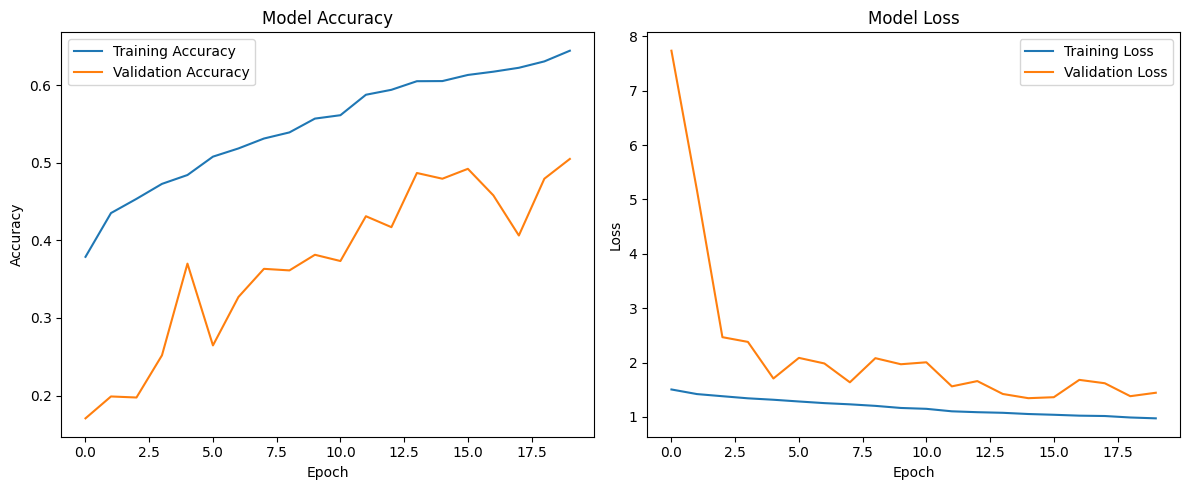

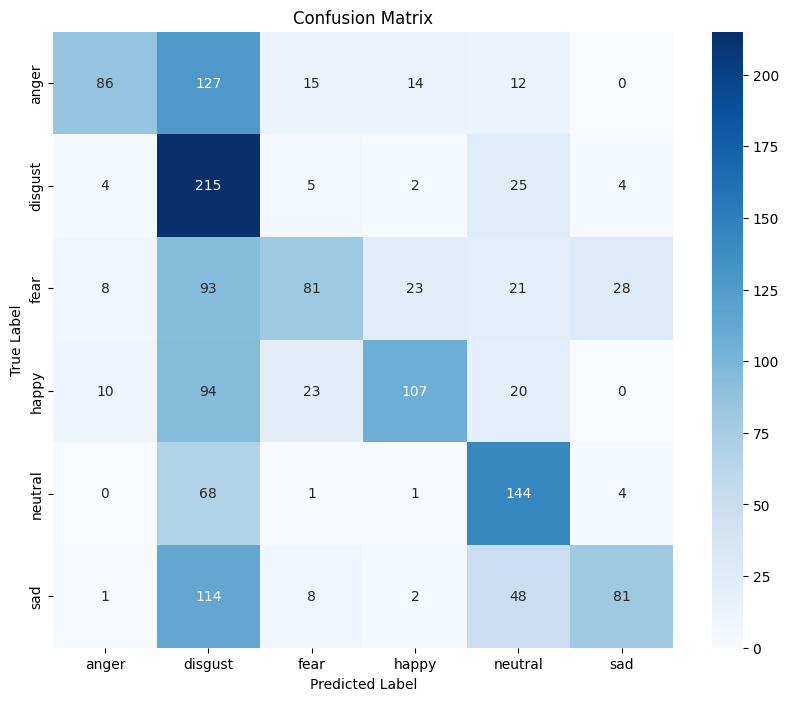

In [7]:
if __name__ == '__main__':
    # Define file paths
    # 1. SET this to where your .npz file is
    DATA_DIR = 'D:/Bhumika/College_Project/Data/Processed_data'
    NPZ_FILE = os.path.join(DATA_DIR, 'aligned_speech_data.npz')
    
    # 2. SET this to where you want to save the trained model
    MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'speech_emotion_model.h5')

    # --- 1. Load Data ---
    features, labels, ids = load_data(NPZ_FILE)
    
    if features is not None:
        # --- 2. Preprocess Data ---
        X, y, encoder = preprocess_data(features, labels)
        
        # --- 3. Split Data ---
        print("\nCheckpoint 1: Starting data split...")
        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
            print("Checkpoint 2: Data split successful.")
            print(f"Training set size: {len(X_train)}")
            print(f"Testing set size:  {len(X_test)}")
        except Exception as e:
            print(f"\n--- ERROR during data split ---")
            print(e)
            exit() # Stop the script if split fails

        # --- 4. Build Model ---
        print("\nCheckpoint 3: Defining input shape and classes...")
        try:
            input_shape = X_train.shape[1:]  # (height, width, channels)
            num_classes = y_train.shape[1]   # Number of emotion classes
            print(f"Input shape: {input_shape}")
            print(f"Num classes: {num_classes}")
            
            print("\nCheckpoint 4: Calling build_model function...")
            model = build_model(input_shape, num_classes)
            
            print("\nCheckpoint 5: Model built. Printing summary...")
            model.summary() # Print a table of the model's architecture
        except Exception as e:
            print(f"\n--- ERROR during model building ---")
            print("This often means there is an issue with your TensorFlow installation.")
            print(e)
            exit() # Stop the script if build fails

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        lr_scheduler = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        )
        # --- 5. Train Model ---
        print("\nCheckpoint 6: Starting model training (model.fit)...")
        try:
            history = model.fit(
                X_train,
                y_train,
                epochs=50,
                batch_size=32,
                validation_data=(X_test, y_test),
                callbacks=[early_stop, lr_scheduler]
            )
            print("\nCheckpoint 7: Model Training Complete.")
        except Exception as e:
            print(f"\n--- ERROR during model training ---")
            print("This can be a GPU/CUDA issue or a data shape mismatch.")
            print(e)
            exit() # Stop the script if training fails

        # --- 6. Evaluate Model ---
        print("\nCheckpoint 8: Plotting training history...")
        plot_training_history(history)
        
        print("\nCheckpoint 9: Evaluating final model...")
        evaluate_model(model, X_test, y_test, encoder)
        
        # --- 7. Save Model ---
        print("\nCheckpoint 10: Saving model...")
        try:
            model.save(MODEL_SAVE_PATH)
            print(f"\nSuccessfully saved trained model to:\n{MODEL_SAVE_PATH}")
            print("\n--- SCRIPT FINISHED SUCCESSFULLY ---")
        except Exception as e:
            print(f"\n--- ERROR saving model ---")
            print(e)



In [8]:
import pickle

encoder_path = os.path.join(DATA_DIR, 'label_encoder.pkl')

with open(encoder_path, 'wb') as f:
    pickle.dump(encoder, f)

print(f"Saved label encoder to: {encoder_path}")

Saved label encoder to: D:/Bhumika/College_Project/Data/Processed_data\label_encoder.pkl
